# Visualização de Estatísticas de Grafos

Este notebook analisa e visualiza as estatísticas de um grafo utilizando a classe `Graph` definida em `main.py`.

In [37]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from IPython.display import display, HTML

# Configuração para melhorar a qualidade dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Importar a classe Graph do arquivo original
from main import Graph

# Instanciar o grafo e carregar os dados
grafo = Graph("selected_instances/BHW1.dat")
grafo.addRoads()

## 1. Estatísticas Básicas do Grafo

Vamos começar exibindo as estatísticas básicas do grafo em formato tabular.

In [38]:
# Criar tabela de estatísticas básicas
stats = {
    'Estatística': [
        'Número de Vértices', 'Número de Arestas', 'Número de Arcos',
        'Vértices Requeridos', 'Arestas Requeridas', 'Arcos Requeridos',
        'Densidade', 'Componentes Conectados', 'Grau Mínimo', 
        'Grau Máximo', 'Caminho Médio', 'Diâmetro'
    ],
    'Valor': [
        grafo.node, grafo.edges, grafo.arc, 
        grafo.reN, grafo.reE, grafo.reA,
        round(grafo.density(), 4), grafo.connectedComp(), 
        grafo.minDegree(), grafo.maxDegree(), 
        round(grafo.averagePathLength(), 4), grafo.maxRoad()
    ]
}

df = pd.DataFrame(stats)

# Estilizar a tabela usando pandas styling
styled_df = df.style.set_properties(**{'text-align': 'left'})

# Destacar valores máximos e mínimos
styled_df = styled_df.highlight_max(subset=['Valor'], color='#8AFF8A')
styled_df = styled_df.highlight_min(subset=['Valor'], color='#FFAAAA')

display(styled_df)

,Estatística,Valor
0,Número de Vértices,12.000000
1,Número de Arestas,11.000000
2,Número de Arcos,22.000000
3,Vértices Requeridos,7.000000
4,Arestas Requeridas,11.000000
5,Arcos Requeridos,11.000000
6,Densidade,0.500000
7,Componentes Conectados,1.000000
8,Grau Mínimo,6.000000
9,Grau Máximo,10.000000


## 2. Análise de Graus dos Vértices

Aqui analisamos os graus de entrada e saída de cada vértice do grafo.

,Nó,Grau de Entrada,Grau de Saída,Grau Total
0,1,5,5,10
1,2,4,4,8
2,3,3,3,6
3,4,3,3,6
4,5,4,4,8
5,6,3,3,6
6,7,4,4,8
7,8,3,3,6
8,9,3,3,6
9,10,4,4,8


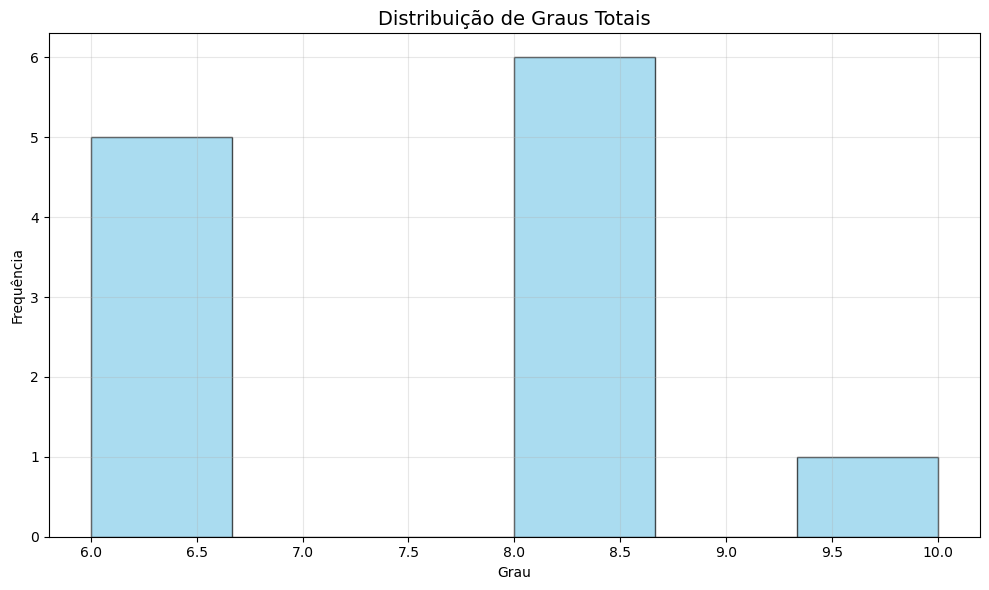

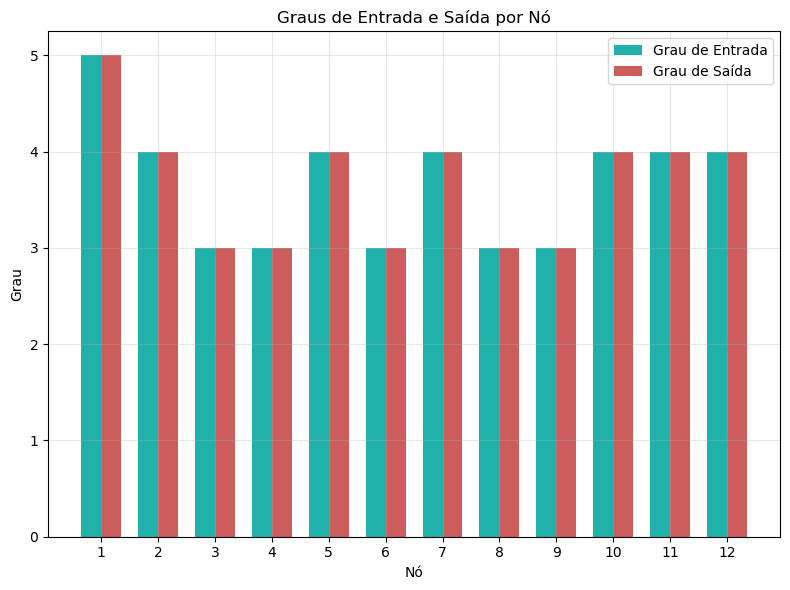

In [39]:
# Calcular graus de entrada e saída
in_degrees = {}
out_degrees = {}
total_degrees = {}

# Inicializar os dicionários
for i in range(1, grafo.node + 1):
    in_degrees[i] = 0
    out_degrees[i] = 0

# Calcular graus
for i in range(grafo.node):
    for j in range(grafo.node):
        if grafo.graph[i][j] != 999 and i != j:
            out_degrees[i+1] += 1
        if grafo.graph[j][i] != 999 and i != j:
            in_degrees[i+1] += 1

# Calcular grau total
for node in range(1, grafo.node + 1):
    total_degrees[node] = in_degrees[node] + out_degrees[node]

# Criar DataFrame para visualização
df_degrees = pd.DataFrame({
    'Nó': list(range(1, grafo.node + 1)),
    'Grau de Entrada': list(in_degrees.values()),
    'Grau de Saída': list(out_degrees.values()),
    'Grau Total': list(total_degrees.values())
})

# Exibir tabela
display(df_degrees.style.highlight_max(subset=['Grau Total'], color='#8AFF8A')
        .highlight_min(subset=['Grau Total'], color='#FFAAAA'))

# Criar histograma para a distribuição de graus
plt.figure(figsize=(10, 6))

# Garantir pelo menos 1 bin
num_bins = max(1, min(10, grafo.node // 2))

plt.hist(df_degrees['Grau Total'], bins=num_bins, 
         alpha=0.7, color='skyblue', edgecolor='black')

plt.title('Distribuição de Graus Totais', fontsize=14)
plt.xlabel('Grau')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Gráfico de barras para graus por nó
plt.figure(figsize=(max(8, grafo.node * 0.5), 6))

x = np.arange(len(df_degrees))  # usar o tamanho real da tabela
width = 0.35

plt.bar(x - width/2, df_degrees['Grau de Entrada'], width, label='Grau de Entrada', color='lightseagreen')
plt.bar(x + width/2, df_degrees['Grau de Saída'], width, label='Grau de Saída', color='indianred')

plt.xlabel('Nó')
plt.ylabel('Grau')
plt.title('Graus de Entrada e Saída por Nó')
plt.xticks(x, df_degrees['Nó'])  # isso espera que 'Nó' seja uma lista contínua
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Visualização Simplificada do Grafo

Abaixo apresentamos uma visualização do grafo, onde os nós são dispostos em círculo. O tamanho de cada nó é proporcional ao seu grau total.

In [40]:
# Calcular graus de entrada e saída
in_degrees = {i: 0 for i in range(grafo.node)}
out_degrees = {i: 0 for i in range(grafo.node)}
total_degrees = {}

# Calcular graus
for i in range(grafo.node):
    for j in range(grafo.node):
        if grafo.graph[i][j] != 999 and i != j:
            out_degrees[i] += 1
        if grafo.graph[j][i] != 999 and i != j:
            in_degrees[i] += 1

# Grau total
for node in range(grafo.node):
    total_degrees[node] = in_degrees[node] + out_degrees[node]

# Criar DataFrame
df_degrees = pd.DataFrame({
    'Nó': [i+1 for i in range(grafo.node)],
    'Grau de Entrada': list(in_degrees.values()),
    'Grau de Saída': list(out_degrees.values()),
    'Grau Total': list(total_degrees.values())
})

# Exibir tabela com destaque
display(df_degrees.style
        .highlight_max(subset=['Grau Total'], color='#8AFF8A')
        .highlight_min(subset=['Grau Total'], color='#FFAAAA'))

,Nó,Grau de Entrada,Grau de Saída,Grau Total
0,1,5,5,10
1,2,4,4,8
2,3,3,3,6
3,4,3,3,6
4,5,4,4,8
5,6,3,3,6
6,7,4,4,8
7,8,3,3,6
8,9,3,3,6
9,10,4,4,8


## 4. Mapa de Calor da Matriz de Adjacência

Visualização da matriz de adjacência como um mapa de calor, mostrando os pesos das conexões entre os nós.

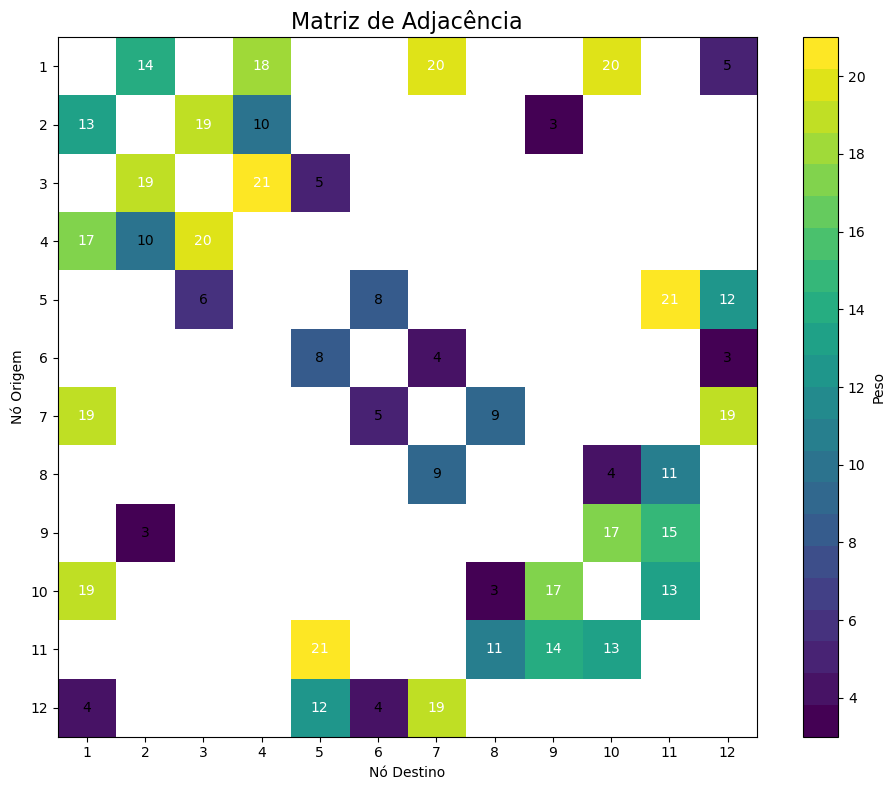

In [41]:
# Mapa de calor da matriz de adjacência
# Criar uma versão da matriz sem valores infinitos para visualização
matriz = np.array(grafo.graph, dtype=float)
mask = matriz == 999
matriz[mask] = np.nan  # Substituir 999 por NaN

plt.figure(figsize=(10, 8))

# Criar matriz de cores
colors = plt.cm.viridis(np.linspace(0, 1, int(np.nanmax(matriz)) + 1 if not np.isnan(np.nanmax(matriz)) else 1))
cmap = plt.cm.colors.ListedColormap(colors)

# Definir limites para garantir que a colorbar inclua todos os valores
vmin = np.nanmin(matriz) if not np.isnan(np.nanmin(matriz)) else 0
vmax = np.nanmax(matriz) if not np.isnan(np.nanmax(matriz)) else 1

# Criar a imagem do mapa de calor
plt.imshow(matriz, interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax)
plt.colorbar(label='Peso')

# Adicionar valores na matriz
for i in range(grafo.node):
    for j in range(grafo.node):
        if not np.isnan(matriz[i, j]):
            plt.text(j, i, f'{int(matriz[i, j])}', ha='center', va='center', 
                     color='white' if matriz[i, j] > vmax/2 else 'black')

plt.title('Matriz de Adjacência', fontsize=16)
plt.xlabel('Nó Destino')
plt.ylabel('Nó Origem')

# Ajustar rótulos para começar do 1 em vez de 0
plt.xticks(range(grafo.node), [i+1 for i in range(grafo.node)])
plt.yticks(range(grafo.node), [i+1 for i in range(grafo.node)])

plt.tight_layout()
plt.show()

## 5. Análise de Caminhos

Vamos analisar os caminhos mais curtos entre os nós do grafo usando o algoritmo de Floyd-Warshall já implementado.

,Estatística,Valor
0,Caminho Médio,17.6806
1,Caminho Máximo (Diâmetro),34.0000
2,Caminho Mínimo,3.0000
3,Desvio Padrão,7.8091


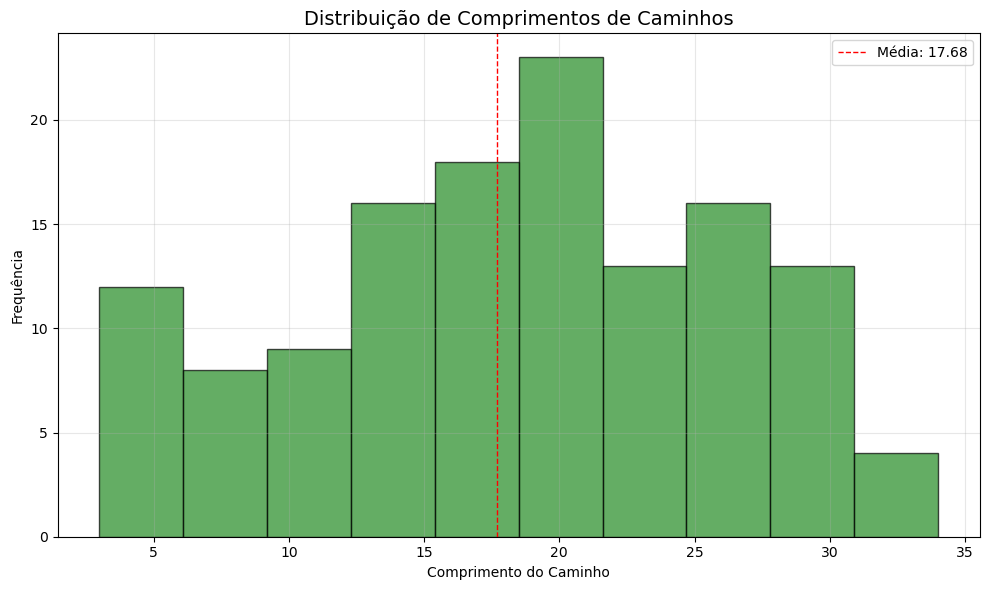

In [42]:
# Calcular matriz de distâncias mais curtas
dist_matrix = grafo.floydWarshall()
matriz_dist = np.array(dist_matrix, dtype=float)
matriz_dist[matriz_dist == 999] = np.nan

# Calcular estatísticas de caminhos
all_paths = []
for i in range(grafo.node):
    for j in range(grafo.node):
        if i != j and not np.isnan(matriz_dist[i, j]):
            all_paths.append(matriz_dist[i, j])

# Estatísticas básicas
path_mean = np.nanmean(matriz_dist) if len(all_paths) > 0 else 0
path_max = np.nanmax(matriz_dist) if len(all_paths) > 0 else 0
path_min = np.nanmin([p for p in all_paths if p > 0]) if len(all_paths) > 0 else 0
path_std = np.nanstd(matriz_dist) if len(all_paths) > 0 else 0

stats = {
    'Estatística': ['Caminho Médio', 'Caminho Máximo (Diâmetro)', 'Caminho Mínimo', 'Desvio Padrão'],
    'Valor': [
        round(path_mean, 4),
        int(path_max),
        int(path_min),
        round(path_std, 4)
    ]
}

df_stats = pd.DataFrame(stats)
display(df_stats)
if len(all_paths) > 0:
    plt.figure(figsize=(10, 6))

    num_bins = max(1, min(10, len(set(all_paths))))  # garante ao menos 1 bin
    plt.hist(all_paths, bins=num_bins, color='forestgreen',
             alpha=0.7, edgecolor='black')
    
    plt.axvline(path_mean, color='red', linestyle='dashed', linewidth=1,
                label=f'Média: {path_mean:.2f}')
    
    plt.title('Distribuição de Comprimentos de Caminhos', fontsize=14)
    plt.xlabel('Comprimento do Caminho')
    plt.ylabel('Frequência')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

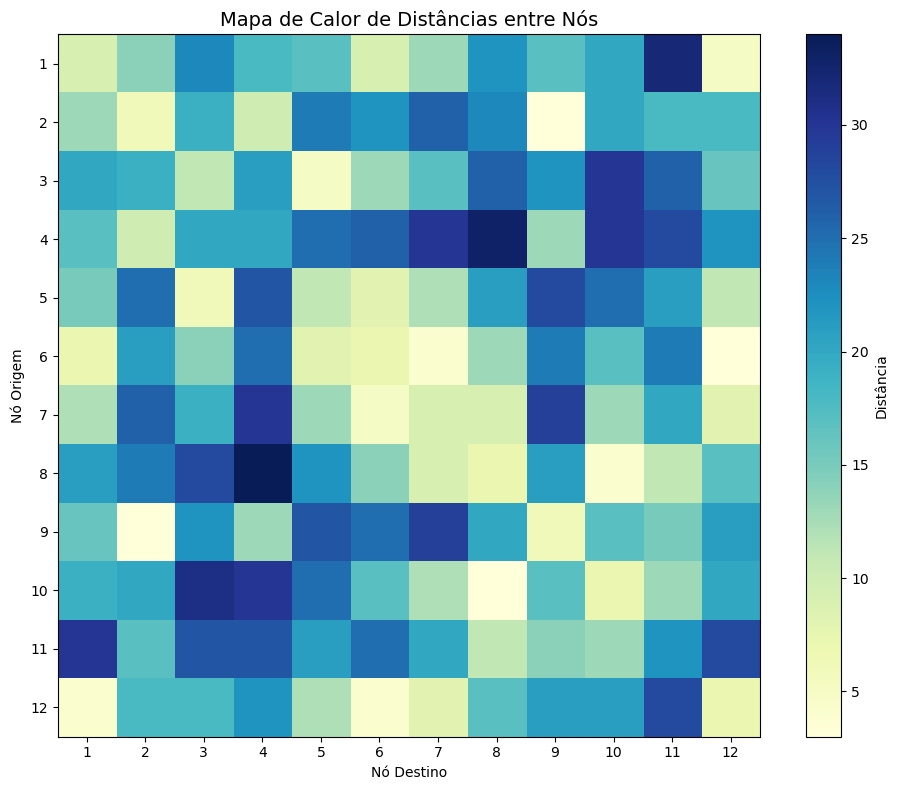

In [43]:
# Mapa de calor das distâncias
plt.figure(figsize=(10, 8))

# Criar mapa de calor
img = plt.imshow(matriz_dist, interpolation='nearest', cmap='YlGnBu')
plt.colorbar(img, label='Distância')

plt.title('Mapa de Calor de Distâncias entre Nós', fontsize=14)
plt.xlabel('Nó Destino')
plt.ylabel('Nó Origem')

# Ajustar rótulos
plt.xticks(range(grafo.node), [i+1 for i in range(grafo.node)])
plt.yticks(range(grafo.node), [i+1 for i in range(grafo.node)])

plt.tight_layout()
plt.show()

## 6. Gráfico Comparativo de Estatísticas

Um gráfico de barras comparando as principais estatísticas do grafo.

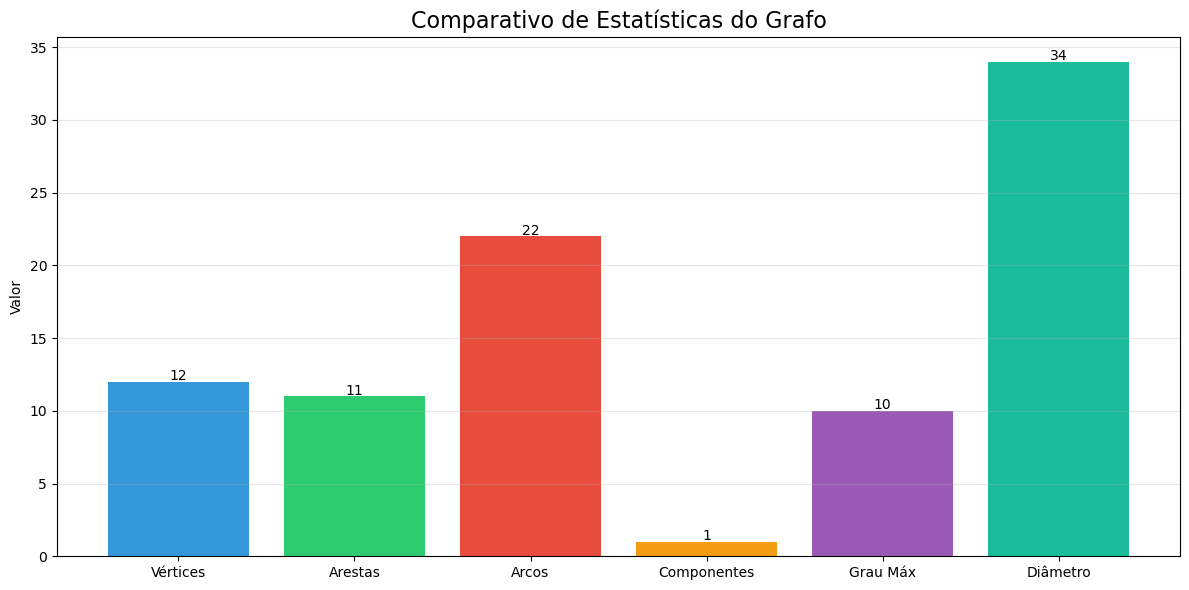

In [44]:
# Valores para comparação
estatisticas = ['Vértices', 'Arestas', 'Arcos', 'Componentes', 'Grau Máx', 'Diâmetro']
valores = [grafo.node, grafo.edges, grafo.arc, grafo.connectedComp(), grafo.maxDegree(), grafo.maxRoad()]

# Criar um gráfico de barras
plt.figure(figsize=(12, 6))

# Cores distintas para cada barra
cores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

plt.bar(estatisticas, valores, color=cores)

# Adicionar os valores no topo das barras
for i, v in enumerate(valores):
    plt.text(i, v + 0.1, str(v), ha='center')

plt.title('Comparativo de Estatísticas do Grafo', fontsize=16)
plt.ylabel('Valor')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Resumo das Descobertas

Vamos resumir as principais características e descobertas sobre o grafo analisado.

In [45]:
# Métricas
densidade = grafo.density() * 100
componentes = grafo.connectedComp()
caminho_medio = grafo.averagePathLength()
diametro = grafo.maxRoad()

# Identificar nós com maior e menor grau (excluindo grau 0)
max_degree_node = max(total_degrees, key=total_degrees.get)
min_degree_node = min(
    (n for n, d in total_degrees.items() if d > 0), 
    key=lambda x: total_degrees[x],
    default=None
)

print("\n===== Resumo das Características do Grafo =====\n")
print(f"O grafo possui {grafo.node} vértices, {grafo.edges} arestas e {grafo.arc} arcos.")
print(f"Densidade: {densidade:.2f}% das possíveis conexões estão presentes.")
print(f"O grafo {'não é' if componentes > 1 else 'é'} conexo (componentes: {componentes}).")

if min_degree_node is not None:
    print(f"\nO nó mais central é o nó {max_degree_node + 1} com grau {total_degrees[max_degree_node]}.")
    print(f"O nó menos conectado (grau > 0) é o nó {min_degree_node + 1} com grau {total_degrees[min_degree_node]}.")
else:
    print("\nNão há nenhum nó com grau maior que 0.")

print(f"\nO caminho médio entre os nós é de {caminho_medio:.2f} unidades.")
print(f"O diâmetro do grafo (maior distância entre quaisquer dois nós) é {diametro}.")


===== Resumo das Características do Grafo =====

O grafo possui 12 vértices, 11 arestas e 22 arcos.
Densidade: 50.00% das possíveis conexões estão presentes.
O grafo é conexo (componentes: 1).

O nó mais central é o nó 1 com grau 10.
O nó menos conectado (grau > 0) é o nó 3 com grau 6.

O caminho médio entre os nós é de 18.36 unidades.
O diâmetro do grafo (maior distância entre quaisquer dois nós) é 34.
